In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### LOAD DATA

In [8]:
df = pd.read_csv(r"..\data\heart_stacking.csv")

print("=" * 55)
print("HEART DISEASE PREDICTION – STACKING ENSEMBLE")
print("=" * 55)
print(df.info())
print("\n── Descriptive Statistics ──")
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())
print(f"\nHeartDisease distribution:\n{df['HeartDisease'].value_counts()}")
print("  (0 = No Disease  |  1 = Disease Present)")

HEART DISEASE PREDICTION – STACKING ENSEMBLE
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Age           120 non-null    int64
 1   Cholesterol   120 non-null    int64
 2   MaxHeartRate  120 non-null    int64
 3   RestingBP     120 non-null    int64
 4   HeartDisease  120 non-null    int64
dtypes: int64(5)
memory usage: 4.8 KB
None

── Descriptive Statistics ──
              Age  Cholesterol  MaxHeartRate   RestingBP  HeartDisease
count  120.000000    120.00000    120.000000  120.000000    120.000000
mean    52.791667    228.90000    140.733333  137.858333      0.691667
std     13.431367     42.71154     32.589046   26.598571      0.463741
min     30.000000    151.00000     90.000000   90.000000      0.000000
25%     43.000000    194.00000    114.250000  115.000000      0.000000
50%     51.500000    234.00000    136.000000  137.000000      1.000000
75%  

### FEATURES & TARGET

In [9]:
feature_names = ['Cholesterol', 'MaxHeartRate', 'Age']
X = df[feature_names]
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (required for LR and SVM)
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


### DEFINE MODELS

In [10]:
lr  = LogisticRegression(max_iter=1000, random_state=42)
svm = SVC(kernel='rbf', probability=True, random_state=42)
dt  = DecisionTreeClassifier(max_depth=4, random_state=42)

# Meta-learner
meta = LogisticRegression(max_iter=1000, random_state=42)

# Stacking classifier
stack = StackingClassifier(
    estimators=[
        ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
        ('SVM',                 SVC(kernel='rbf', probability=True, random_state=42)),
        ('Decision Tree',       DecisionTreeClassifier(max_depth=4, random_state=42)),
    ],
    final_estimator=meta,
    cv=5,
    passthrough=False
)


### TRAIN & EVALUATE ALL MODELS

In [11]:
models = {
    'Logistic Regression' : lr,
    'SVM'                 : svm,
    'Decision Tree'       : dt,
    'Stacking Ensemble'   : stack,
}

results = {}

print("\n" + "=" * 55)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 55)
print(f"{'Model':<22}  {'Train Acc':>9}  {'Test Acc':>9}  {'CV Mean':>9}  {'CV Std':>7}")
print("-" * 60)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_test_sc)
    tr_acc  = accuracy_score(y_train, model.predict(X_train_sc))
    te_acc  = accuracy_score(y_test,  y_pred)
    cv      = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy')
    results[name] = {'train': tr_acc, 'test': te_acc,
                     'cv_mean': cv.mean(), 'cv_std': cv.std(),
                     'y_pred': y_pred}
    print(f"{name:<22}  {tr_acc:>9.4f}  {te_acc:>9.4f}  "
          f"{cv.mean():>9.4f}  {cv.std():>7.4f}")

# Detailed report for Stacking
print("\n── Stacking Ensemble – Detailed Report ──")
print(classification_report(y_test, results['Stacking Ensemble']['y_pred'],
                             target_names=["No Disease", "Disease"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, results['Stacking Ensemble']['y_pred']))


MODEL PERFORMANCE COMPARISON
Model                   Train Acc   Test Acc    CV Mean   CV Std
------------------------------------------------------------
Logistic Regression        0.7396     0.7083     0.7084   0.0528
SVM                        0.7708     0.7917     0.6253   0.0755
Decision Tree              0.8958     0.6250     0.7179   0.0737
Stacking Ensemble          0.8750     0.7500     0.6979   0.0204

── Stacking Ensemble – Detailed Report ──
              precision    recall  f1-score   support

  No Disease       0.57      0.57      0.57         7
     Disease       0.82      0.82      0.82        17

    accuracy                           0.75        24
   macro avg       0.70      0.70      0.70        24
weighted avg       0.75      0.75      0.75        24

Confusion Matrix:
[[ 4  3]
 [ 3 14]]


### VISUALISATION – Model Comparison Bar Chart

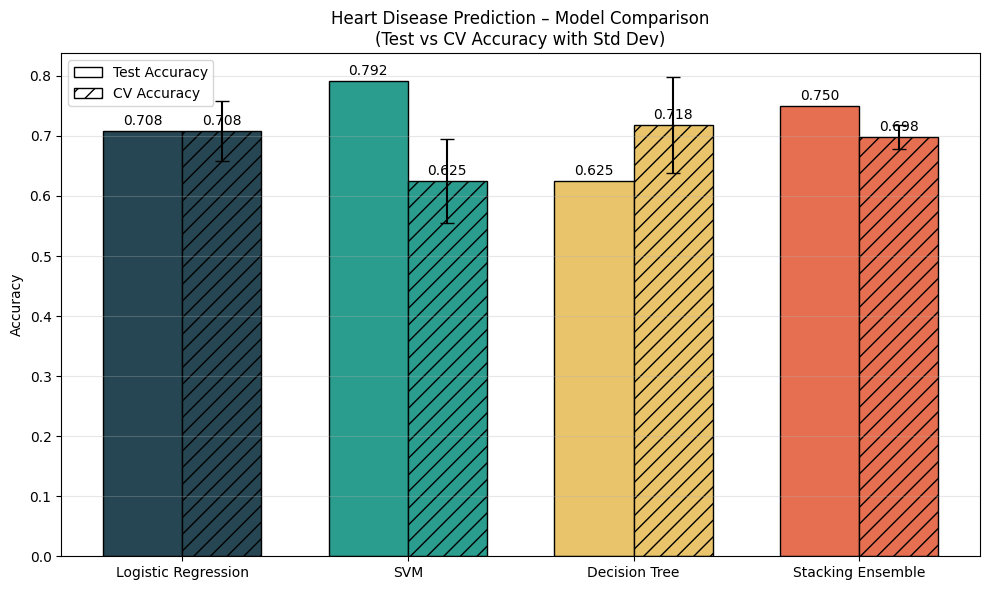

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

models = ['Logistic Regression', 'SVM', 'Decision Tree', 'Stacking Ensemble']

test_acc = [0.708, 0.792, 0.625, 0.750]
cv_acc   = [0.708, 0.625, 0.718, 0.698]
cv_std   = [0.05, 0.07, 0.08, 0.02]

colors = ['#264653', '#2A9D8F', '#E9C46A', '#E76F51']

x = np.arange(len(models))
bar_width = 0.35

plt.figure(figsize=(10, 6))

# ── Test bars (solid)
for i in range(len(models)):
    plt.bar(x[i] - bar_width/2, test_acc[i],
            width=bar_width,
            color=colors[i],
            edgecolor='black',
            hatch='')

# ── CV bars (patterned)
for i in range(len(models)):
    plt.bar(x[i] + bar_width/2, cv_acc[i],
            width=bar_width,
            color=colors[i],
            edgecolor='black',
            hatch='//',
            yerr=cv_std[i],
            capsize=5)

# Labels
plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Heart Disease Prediction – Model Comparison\n(Test vs CV Accuracy with Std Dev)")

# ─────────────────────────────────────────
# LEGEND (PATTERN-BASED, NOT COLOR)
# ─────────────────────────────────────────
legend_elements = [
    Patch(facecolor='white', edgecolor='black', hatch='', label='Test Accuracy'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='CV Accuracy')
]

plt.legend(handles=legend_elements, loc='upper left')

# Annotate values
for i in range(len(models)):
    plt.text(x[i] - bar_width/2, test_acc[i] + 0.01,
             f"{test_acc[i]:.3f}", ha='center')

    plt.text(x[i] + bar_width/2, cv_acc[i] + 0.01,
             f"{cv_acc[i]:.3f}", ha='center')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()